In [11]:
# Import des librairie importantes
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from numba import njit

# Quelques généralités importante dans le layout des figures
plt.rcParams.update({'font.size': 16})
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['lines.markersize'] = 5
cmap = "coolwarm"

In [20]:
class Network:
    '''
    Classe pour initaliser un réseau comme dans l'article
    '''
    def __init__(self, N: int, tau: float, alpha: float):
        self.N = N
        self.tau= tau
        self.g = 1.5
        
        self.J = np.random.normal(loc=0.0, scale=np.sqrt(self.g**2/(self.N)), size=(self.N, self.N)) 
        self.P = 1/alpha * np.identity(n=self.N)
        self.x = np.random.uniform(low=-1.0, high=1.0, size=(self.N, 1))
        self.h = np.random.uniform(low=-1.0, high=1.0, size=(self.N, 1))
        
    def dxdt(self):
        return 1/self.tau * (-self.x + self.g * self.J @ np.tanh(self.x) + self.h)
    
    def dhdt(self):
        eta = np.random.normal(loc=0.0, scale=1.0, size=(self.N, 1))
        return 1/0.1 * (-self.h + eta)
    
    def update_J(self, f: np.array):
        cte = (1/(1 + np.tanh(self.x).T @ self.P @ np.tanh(self.x)))[0][0]
        error = np.tanh(self.x) - f
        self.P = self.P - self.P @ np.tanh(self.x) @ np.tanh(self.x).T @ self.P / (1 + np.tanh(self.x).T @ self.P @ np.tanh(self.x))
        self.J = self.J - cte * error @ (self.P @ np.tanh(self.x)).T
        return None
    
    def integrate(self, time: np.array):
        dt = time[1]-time[0]
        x = np.empty((self.N, len(time)))
        for i, t in enumerate(time):
            self.h = self.h + dt * self.dhdt()
            self.x = self.x + dt * self.dxdt()
            x[:, i] = self.x[:, 0]
        return x
    
    def learn(self, time: np.array, signal: np.array):
        dt = time[1]-time[0]
        J = np.empty(len(time))
        x = np.empty((self.N, len(time)))
        f = np.empty((self.N, 1))
        err = []
        for i in range(len(time)):
            f[:, 0] = signal[:, i]
            self.h = self.h + dt * self.dhdt()
            self.x = self.x + dt * self.dxdt()

            x[:, i] = self.x[:, 0]
            
            if not (i+1) % 2:
                self.update_J(f)
            J[i] = np.mean(abs(self.J), axis=(0,1))
            
        return x, J 

### La Numba version

In [12]:
@njit
def dxdt(tau,x,g,J,h):
    return 1/tau * (-x + g * J @ np.tanh(x) + h)

In [13]:
@njit
def dhdt(N,h):
    eta = np.random.normal(loc=0.0, scale=1.0, size=(N, 1))
    return 1/0.1 * (-h + eta)

In [14]:
@njit
def update_J(x, P, J, f):
    cte = (1/(1 + np.tanh(x).T @ P @ np.tanh(x)))[0][0]
    error = np.tanh(x) - f
    P = P - P @ np.tanh(x) @ np.tanh(x).T @ P / (1 + np.tanh(x).T @ P @ np.tanh(x))
    J = J - cte * error @ (P @ np.tanh(x)).T
    return P, J

In [15]:
@njit
def integrate(time, N, tau, ix, g, J, h):
    dt = time[1]-time[0]
    x = np.empty((N, len(time)))
    for i, t in enumerate(time):
        h = h + dt * dhdt(N,h)
        ix = ix + dt * dxdt(tau,ix,g,J,h)
        x[:, i] = ix[:, 0]
    return x

In [16]:
@njit
def learn(N : int, ix, time: np.array, signal: np.array,tau,g,iJ,h):
    dt = time[1]-time[0]
    J = np.empty(len(time))
    x = np.empty((N, len(time)))
    f = np.empty((N, 1))
    err = []
    for i in range(len(time)):
        f[:, 0] = signal[:, i]
        h = h + dt * dhdt(N,h)
        ix = ix + dt * dxdt(tau,ix,g,iJ,h)

        x[:, i] = ix[:, 0]

        if not (i+1) % 2:
            update_J(x, P, J, f)
        J[i] = np.mean(abs(iJ), axis=(0,1))

    return x, J 

## Ancien code

In [17]:
class GeneratorModel2R:
    def __init__(self, N: int, g_AB: tuple, w_rgn: float, p_rgn: float):
        self.N = N
        self.tau = 0.1
        self.w_rgn = w_rgn
        self.w_in = 1.0
        self.p_rgn = p_rgn
        
        self.J = np.empty((2*self.N, 2*self.N))
        for i in range(2):
            for j in range(2):
                if i == j:
                    dist = g_AB[i] * np.random.normal(loc=0.0, scale=np.sqrt(g_AB[i]**2/(self.N)), size=(self.N, self.N))
                else:
                    dist =  self.w_rgn * np.random.choice([0.0, 1.0], size=(self.N, self.N), p=[1-self.p_rgn, self.p_rgn])
                self.J[i*self.N:(i+1)*self.N, j*self.N:(j+1)*N] = dist
        
        self.C_S = np.random.choice([0.0, 1.0], size=(2*self.N, 1), p=[1-0.33, 0.33])

        self.r = np.random.uniform(low=-1.0, high=1.0, size=(2*self.N, 1))
    
    def drdt(self, S: np.array):
        dr = 1/self.tau * (-self.r + self.J @ np.tanh(self.r) + self.w_in * self.C_S * S)
        return dr
    
    def signal(self, t: float):
        if t < 2.0:
            S_A, S_B = 0.0, 0.0
        else:
            S_A = np.sin(2*(np.pi/8)*t + np.pi/3)
            S_B = np.sin(2*(np.pi/3)*t)
        S = np.concatenate((np.full((self.N, 1), S_A), np.full((self.N, 1), S_B)))
        return S
    
    def integrate(self, time: np.array):
        h = time[1]-time[0]
        rA = np.empty((self.N, len(time)))
        rB = np.empty((self.N, len(time)))
        for i, t in enumerate(time):
            S = self.signal(t)
            dr = self.drdt(S)
            self.r = self.r + h * dr
            rA[:, i] = self.r[:self.N, 0]
            rB[:, i] = self.r[self.N:, 0]
        return rA, rB

In [18]:
class GeneratorModel3R:
    def __init__(self, N: int, g_AB: tuple, w_rgn: float, p_rgn: float):
        self.N = N
        self.tau = 0.1
        self.w_in = 1.0
        self.p_rgn = p_rgn
        
        self.J = np.empty((3*self.N, 3*self.N))
        for i in range(3):
            for j in range(3):
                if i == j:
                    dist = g_AB[i] * np.random.normal(loc=0.0, scale=np.sqrt(g_AB[i]**2/(self.N)), size=(self.N, self.N))
                else:
                    dist =  w_rgn * np.random.choice([0.0, 1.0], size=(self.N, self.N), p=[1-self.p_rgn, self.p_rgn])
                self.J[i*self.N:(i+1)*self.N, j*self.N:(j+1)*N] = dist
        C_SA = np.zeros((self.N, 1))
        C_SB = np.random.choice([0.0, -1.0], size=(self.N, 1), p=[1-0.5, 0.5])
        C_SC = np.random.choice([0.0, 1.0], size=(self.N, 1), p=[1-0.5, 0.5])
        self.C_S = self.w_in * np.concatenate((C_SA, C_SB, C_SC))

        self.r = np.random.uniform(low=-1.0, high=1.0, size=(3*self.N, 1))
    
    def drdt(self, S: np.array):
        dr = 1/self.tau * (-self.r + self.J @ np.tanh(self.r) + self.C_S * S)
        return dr
    
    def signal(self, t: float):
        def SQ(t: float):
            indices = np.arange(self.N).reshape(self.N, 1)
            num = (indices - 200 - self.N*t/10)**2
            den = 2 * (200)**2
            return np.exp(-num/den)
        if t < 2.0:
            S_B = SQ(2.0)
            S_C = SQ(2.0)
        elif t < 6.0:
            S_B = SQ(t)
            S_C = SQ(2.0)
        elif t < 8.0:
            S_B = SQ(6.0)
            S_C = SQ(2.0)
        else:
            S_B = SQ(6.0)
            S_C = SQ(5.0)

        S = np.concatenate((np.full((self.N, 1), 0.0), S_B,  S_C))
        return S
    
    def integrate(self, time: np.array):
        h = time[1]-time[0]
        rA = np.empty((self.N, len(time)))
        rB = np.empty((self.N, len(time)))
        rC = np.empty((self.N, len(time)))
        for i, t in enumerate(time):
            S = self.signal(t)
            dr = self.drdt(S)
            self.r = self.r + h * dr
            rA[:, i] = self.r[:self.N, 0]
            rB[:, i] = self.r[self.N:2*self.N, 0]
            rC[:, i] = self.r[2*self.N:, 0]
        return rA, rB, rC

In [21]:
def compute_currents(network: Network, region_size: int, no_regions: int, activity: np.array):    
    currents = [None] * no_regions**2
    k = 0
    for i in range(no_regions):
        for j in range(no_regions):
            neurons_subset = activity[j*region_size:(j+1)*region_size, :]
            J_subset = network.J[i*region_size:(i+1)*region_size, j*region_size:(j+1)*region_size]
            currents[k] = J_subset @ neurons_subset
            k += 1
    
    return currents

### 2 regions model

In [22]:
model = GeneratorModel2R(N=1000, g_AB=[1.8, 1.5], w_rgn=0.01, p_rgn=0.05)
time = np.arange(0.0, 10.0, 0.01)

#rA, rB = model.integrate(time=time)
#np.save("2R_rA.npy", rA)
#np.save("2R_rB.npy", rB)
#np.save("2R_modelJ.npy", model.J)

rA = np.load("2R_rA.npy")
rB = np.load("2R_rB.npy")
model.J = np.load("2R_modelJ.npy")

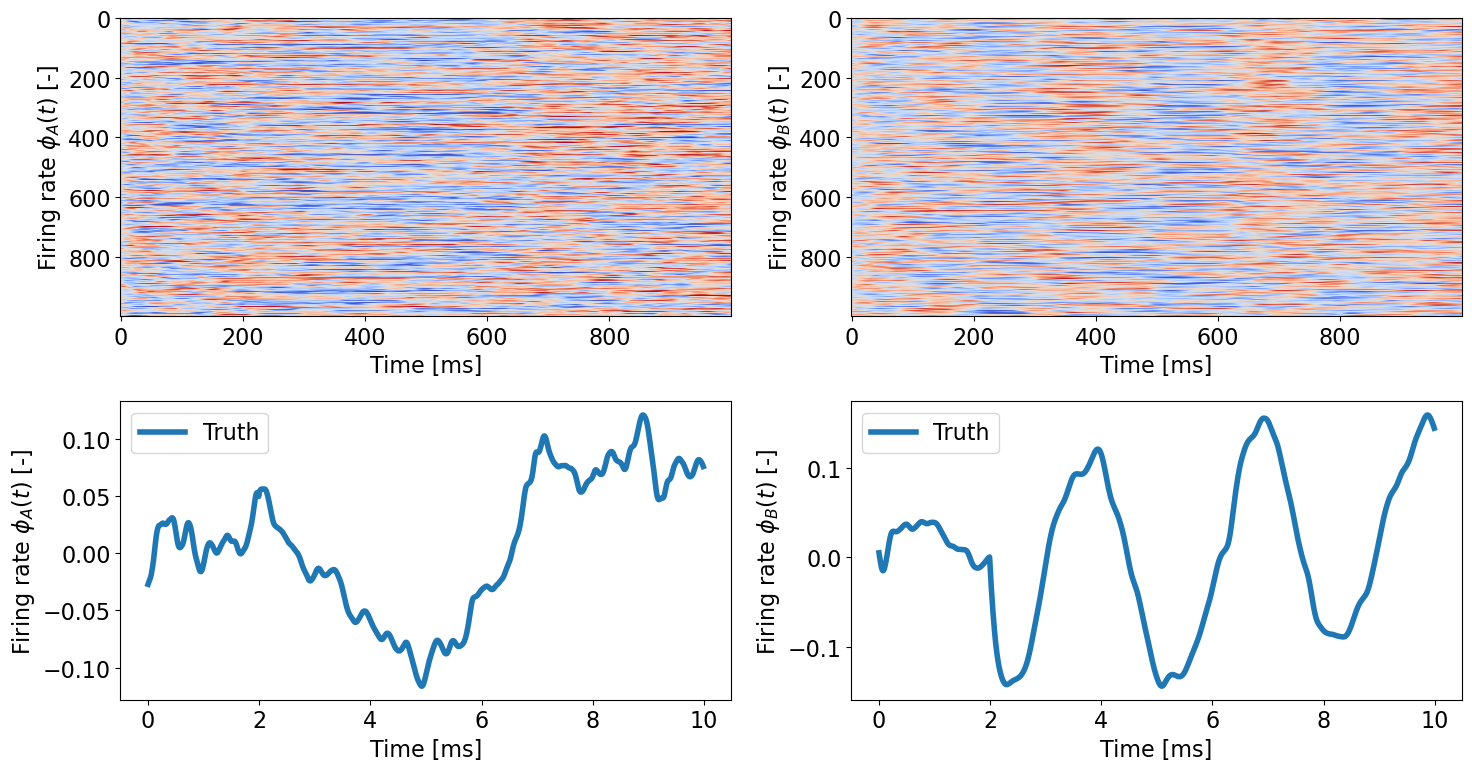

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))

ax1.imshow(np.tanh(rA), aspect="auto", cmap=cmap, vmin=-1.0, vmax=1.0)
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax2.imshow(np.tanh(rB), aspect="auto", cmap=cmap, vmin=-1.0, vmax=1.0)
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Firing rate $\phi_B(t)$ [-]") 

ax3.plot(time, np.mean(np.tanh(rA), axis=0), label="Truth")
ax3.legend()
ax3.set_xlabel("Time [ms]")
ax3.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax4.plot(time, np.mean(np.tanh(rB), axis=0), label="Truth")
ax4.legend()
ax4.set_xlabel("Time [ms]")
ax4.set_ylabel("Firing rate $\phi_B(t)$ [-]")

plt.tight_layout()
plt.show()

In [12]:
net = Network(N=2000, tau=0.1, alpha=1.0)
teacher = np.concatenate((np.tanh(rA), np.tanh(rB)))

# allJ = np.array([])
# for i in tqdm(range(50)):
#     x, J = net.learn(time, teacher)
#     allJ = np.append(allJ, J)
# np.save("CURBdata/2R_training", allJ)
# np.save("CURBdata/2R_netJ", net.J)
# np.save("CURBdata/2R_x", x)

net.J = np.load("CURBdata/2R_netJ.npy")
allJ = np.load("CURBdata/2R_training.npy")
x = np.load("CURBdata/2R_x.npy")

FileNotFoundError: [Errno 2] No such file or directory: 'CURBdata/2R_netJ.npy'

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

ax1.plot(allJ, color="black")
ax1.set_xlabel("Time [-]")
ax1.set_ylabel("J [-]")

plt.tight_layout()
plt.show()

In [14]:
N = 1000
modelA, modelB = x[:N, :], x[N:, :]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))

ax1.imshow(np.tanh(modelA), aspect="auto", cmap=cmap, vmin=-1.0, vmax=1.0)
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax2.imshow(np.tanh(modelB), aspect="auto", cmap=cmap, vmin=-1.0, vmax=1.0)
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Firing rate $\phi_B(t)$ [-]") 

ax3.plot(time, np.mean(np.tanh(modelA), axis=0), label="RNN")
ax3.plot(time, np.mean(np.tanh(rA), axis=0), label="Truth")
ax3.legend()
ax3.set_xlabel("Time [ms]")
ax3.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax4.plot(time, np.mean(np.tanh(modelB), axis=0), label="RNN")
ax4.plot(time, np.mean(np.tanh(rB), axis=0), label="Truth")
ax4.legend()
ax4.set_xlabel("Time [ms]")
ax4.set_ylabel("Firing rate $\phi_B(t)$ [-]")

plt.tight_layout()
plt.show()

NameError: name 'x' is not defined

In [13]:
currents = compute_currents(network=net, region_size=1000, no_regions=2, activity=np.tanh(x))
currents_truth = compute_currents(network=model, region_size=1000, no_regions=2, activity=np.concatenate((np.tanh(rA), np.tanh(rB)), axis=0))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))

ax1.plot(time, np.sum(currents[0], axis=0), label="RNN")
ax1.plot(time, np.sum(currents_truth[0], axis=0), label="Truth")
ax1.legend()
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("Currents A to A")

ax2.plot(time, np.sum(currents[1], axis=0), label="RNN")
ax2.plot(time, np.sum(currents_truth[1], axis=0), label="Truth")
ax2.legend()
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Currents B to A")

ax3.plot(time, np.sum(currents[2], axis=0), label="RNN")
ax3.plot(time, np.sum(currents_truth[2], axis=0), label="Truth")
ax3.legend()
ax3.set_xlabel("Time [ms]")
ax3.set_ylabel("Currents A to B")

ax4.plot(time, np.sum(currents[3], axis=0), label="RNN")
ax4.plot(time, np.sum(currents_truth[3], axis=0), label="Truth")
ax4.legend()
ax4.set_xlabel("Time [ms]")
ax4.set_ylabel("Currents B to B")

plt.tight_layout()
plt.show()

NameError: name 'x' is not defined

In [ ]:
pca_RNN = [None] * len(currents)
for i, curr in enumerate(currents):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_RNN[i] = norm_component
    
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))

ax1.plot(time, -pca_RNN[0], label="RNN")
ax1.plot(time, -pca_truth[0], label="Truth")
ax1.legend()
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("Currents A to A")

ax2.plot(time, pca_RNN[1], label="RNN")
ax2.plot(time, pca_truth[1], label="Truth")
ax2.legend()
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Currents B to A")

ax3.plot(time, -pca_RNN[2], label="RNN")
ax3.plot(time, pca_truth[2], label="Truth")
ax3.legend()
ax3.set_xlabel("Time [ms]")
ax3.set_ylabel("Currents A to B")

ax4.plot(time, pca_RNN[3], label="RNN")
ax4.plot(time, pca_truth[3], label="Truth")
ax4.legend()
ax4.set_xlabel("Time [ms]")
ax4.set_ylabel("Currents B to B")

plt.tight_layout()
plt.show()

### 3 regions model

In [23]:
model = GeneratorModel3R(N=1000, g_AB=[1.8, 1.5, 1.5], w_rgn=0.01, p_rgn=0.01)
time = np.arange(0.0, 12.0, 0.01)

#rA, rB, rC = model.integrate(time=time)
#np.save("3R_rA.npy", rA)
#np.save("3R_rB.npy", rB)
#np.save("3R_rC.npy", rC)
#np.save("3R_modelJ.npy", model.J)

rA = np.load("3R_rA.npy")
rB = np.load("3R_rB.npy")
rC = np.load("3R_rC.npy")
model.J = np.load("3R_modelJ.npy")

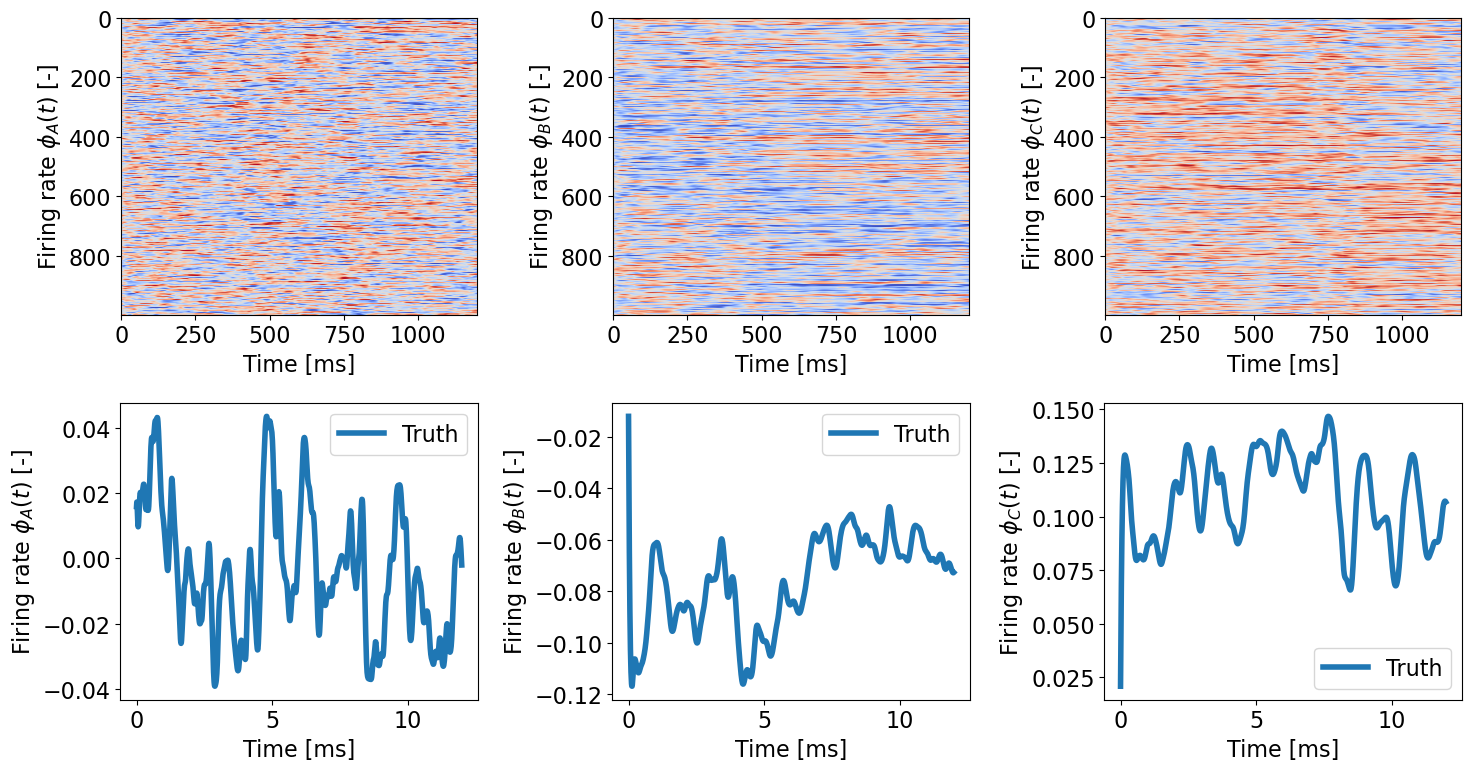

In [17]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 8))

ax1.imshow(np.tanh(rA), cmap=cmap, vmin=-1.0, vmax=1.0)
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax2.imshow(np.tanh(rB), cmap=cmap, vmin=-1.0, vmax=1.0)
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Firing rate $\phi_B(t)$ [-]") 

ax3.imshow(np.tanh(rC), cmap=cmap, vmin=-1.0, vmax=1.0)
ax3.set_xlabel("Time [ms]")
ax3.set_ylabel("Firing rate $\phi_C(t)$ [-]") 

ax4.plot(time, np.mean(np.tanh(rA), axis=0), label="Truth")
ax4.legend()
ax4.set_xlabel("Time [ms]")
ax4.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax5.plot(time, np.mean(np.tanh(rB), axis=0), label="Truth")
ax5.legend()
ax5.set_xlabel("Time [ms]")
ax5.set_ylabel("Firing rate $\phi_B(t)$ [-]")

ax6.plot(time, np.mean(np.tanh(rC), axis=0), label="Truth")
ax6.legend()
ax6.set_xlabel("Time [ms]")
ax6.set_ylabel("Firing rate $\phi_C(t)$ [-]")

plt.tight_layout()
plt.show()


In [18]:
net = Network(N=3000, tau=0.1, alpha=1.0)
teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)

allJ = np.array([])
for i in tqdm(range(10)):
    x, J = net.learn(time, teacher)
    allJ = np.append(allJ, J)
np.save("3R_training.npy", allJ)
np.save("3R_netJ.npy", net.J)
np.save("3R_x.npy", x)

#net.J = np.load("CURBdata/3R_netJ.npy")
#allJ = np.load("CURBdata/3R_training.npy")
#x = np.load("CURBdata/3R_x.npy")

100%|█████████████████████████████████████████████████████████████████████████████| 10/10 [27:04:08<00:00, 9744.83s/it]


In [25]:
# On défini un network hors classe

N = 3000
tau = 0.1
alpha = 1.0
g = 1.5
J = np.random.normal(loc=0.0, scale=np.sqrt(g**2/(N)), size=(N, N)) 
P = 1/alpha * np.identity(n=N)
x = np.random.uniform(low=-1.0, high=1.0, size=(N, 1))
h = np.random.uniform(low=-1.0, high=1.0, size=(N, 1))

teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)

allJ = np.array([])
for i in tqdm(range(10)):
    x, J = learn(N, x, time, teacher ,tau,g,J,h)
    allJ = np.append(allJ, J)
np.save("3R_training_numba.npy", allJ)
np.save("3R_netJ_numba.npy", net.J)
np.save("3R_x_numba.npy", x)

  0%|                                                                                           | 0/10 [00:05<?, ?it/s]


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(<built-in function abs>) found for signature:
 
 >>> abs(array(float64, 2d, C))
 
There are 6 candidate implementations:
[1m  - Of which 2 did not match due to:
  Type Restricted Function in function 'abs': File: unknown: Line unknown.
    With argument(s): '(array(float64, 2d, C))':[0m
[1m   No match for registered cases:
    * (int8,) -> int8
    * (int16,) -> int16
    * (int32,) -> int32
    * (int64,) -> int64
    * (uint8,) -> uint8
    * (uint16,) -> uint16
    * (uint32,) -> uint32
    * (uint64,) -> uint64
    * (float32,) -> float32
    * (float64,) -> float64
    * (complex64,) -> float32
    * (complex128,) -> float64[0m
[1m  - Of which 4 did not match due to:
  Overload of function 'abs': File: <numerous>: Line N/A.
    With argument(s): '(array(float64, 2d, C))':[0m
[1m   No match.[0m
[0m
[0m[1mDuring: resolving callee type: Function(<built

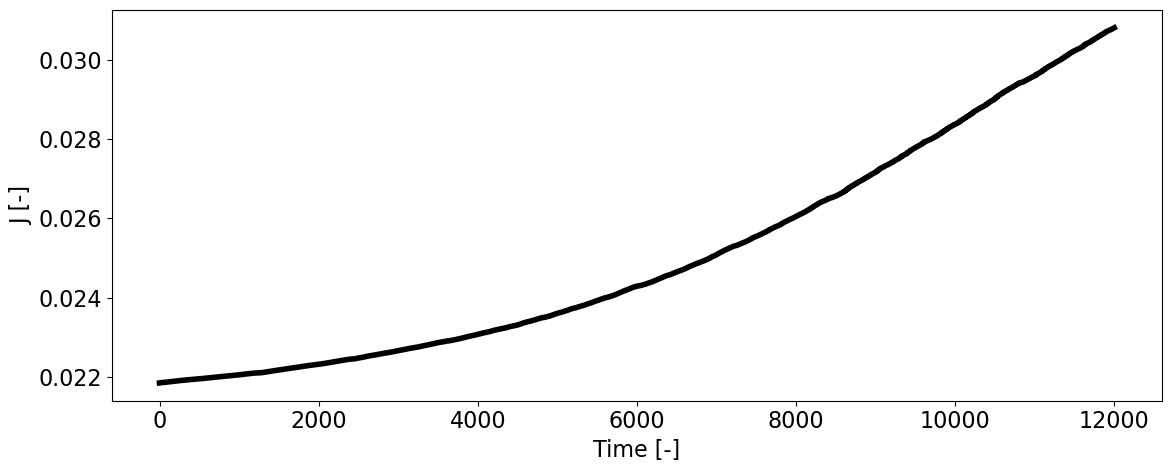

In [19]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))

ax1.plot(allJ, color="black")
ax1.set_xlabel("Time [-]")
ax1.set_ylabel("J [-]")

plt.tight_layout()
plt.show()

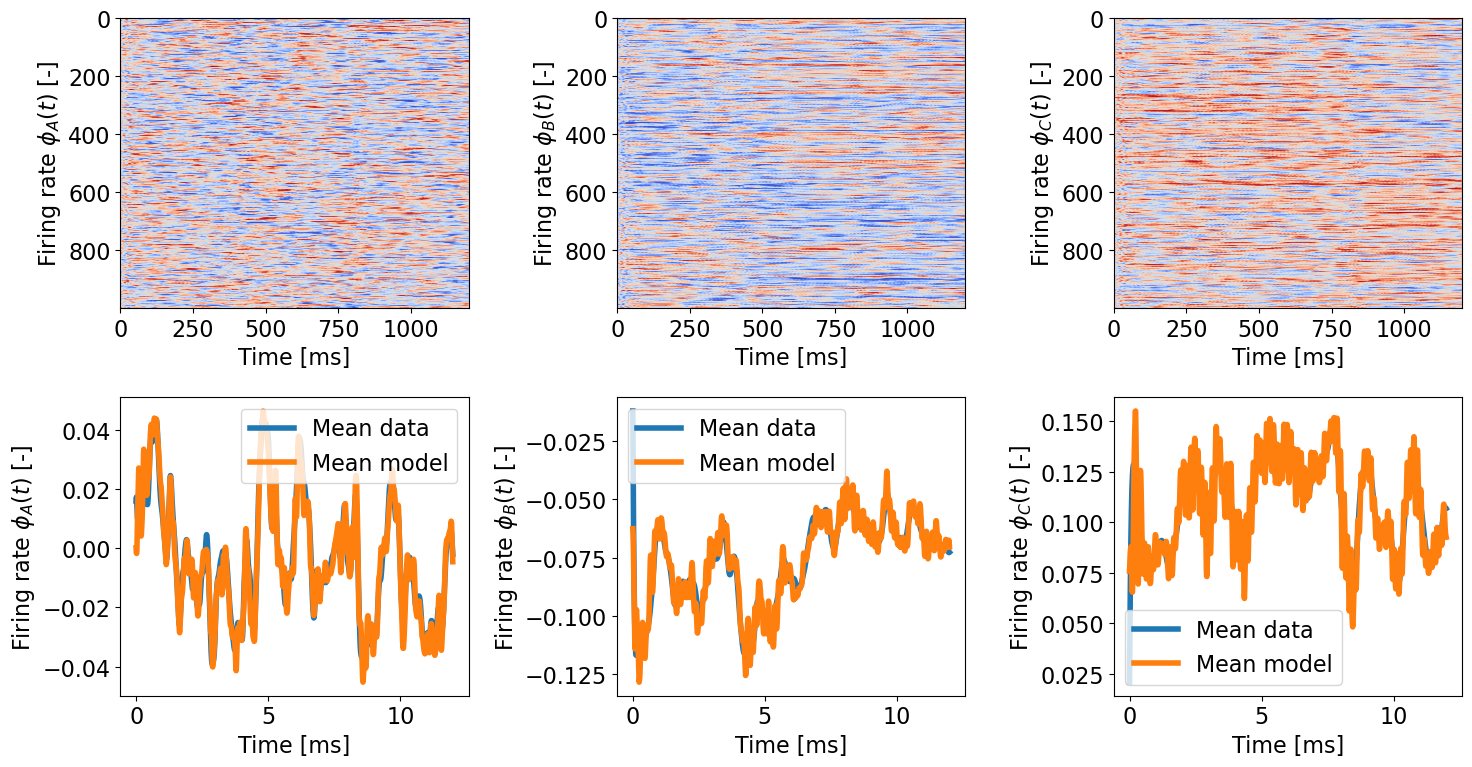

In [20]:
N = 1000
modelA, modelB, modelC = x[:N, :], x[N:2*N, :], x[2*N:, :]

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(15, 8))

ax1.imshow(np.tanh(modelA), cmap=cmap, vmin=-1.0, vmax=1.0)
ax1.set_xlabel("Time [ms]")
ax1.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax2.imshow(np.tanh(modelB), cmap=cmap, vmin=-1.0, vmax=1.0)
ax2.set_xlabel("Time [ms]")
ax2.set_ylabel("Firing rate $\phi_B(t)$ [-]") 

ax3.imshow(np.tanh(modelC), cmap=cmap, vmin=-1.0, vmax=1.0)
ax3.set_xlabel("Time [ms]")
ax3.set_ylabel("Firing rate $\phi_C(t)$ [-]") 

ax4.plot(time, np.mean(np.tanh(rA), axis=0), label="Mean data")
ax4.plot(time, np.mean(np.tanh(modelA), axis=0), label="Mean model")
ax4.legend()
ax4.set_xlabel("Time [ms]")
ax4.set_ylabel("Firing rate $\phi_A(t)$ [-]")

ax5.plot(time, np.mean(np.tanh(rB), axis=0), label="Mean data")
ax5.plot(time, np.mean(np.tanh(modelB), axis=0), label="Mean model")
ax5.legend()
ax5.set_xlabel("Time [ms]")
ax5.set_ylabel("Firing rate $\phi_B(t)$ [-]")

ax6.plot(time, np.mean(np.tanh(rC), axis=0), label="Mean data")
ax6.plot(time, np.mean(np.tanh(modelC), axis=0), label="Mean model")
ax6.legend()
ax6.set_xlabel("Time [ms]")
ax6.set_ylabel("Firing rate $\phi_C(t)$ [-]")

plt.tight_layout()
plt.show()

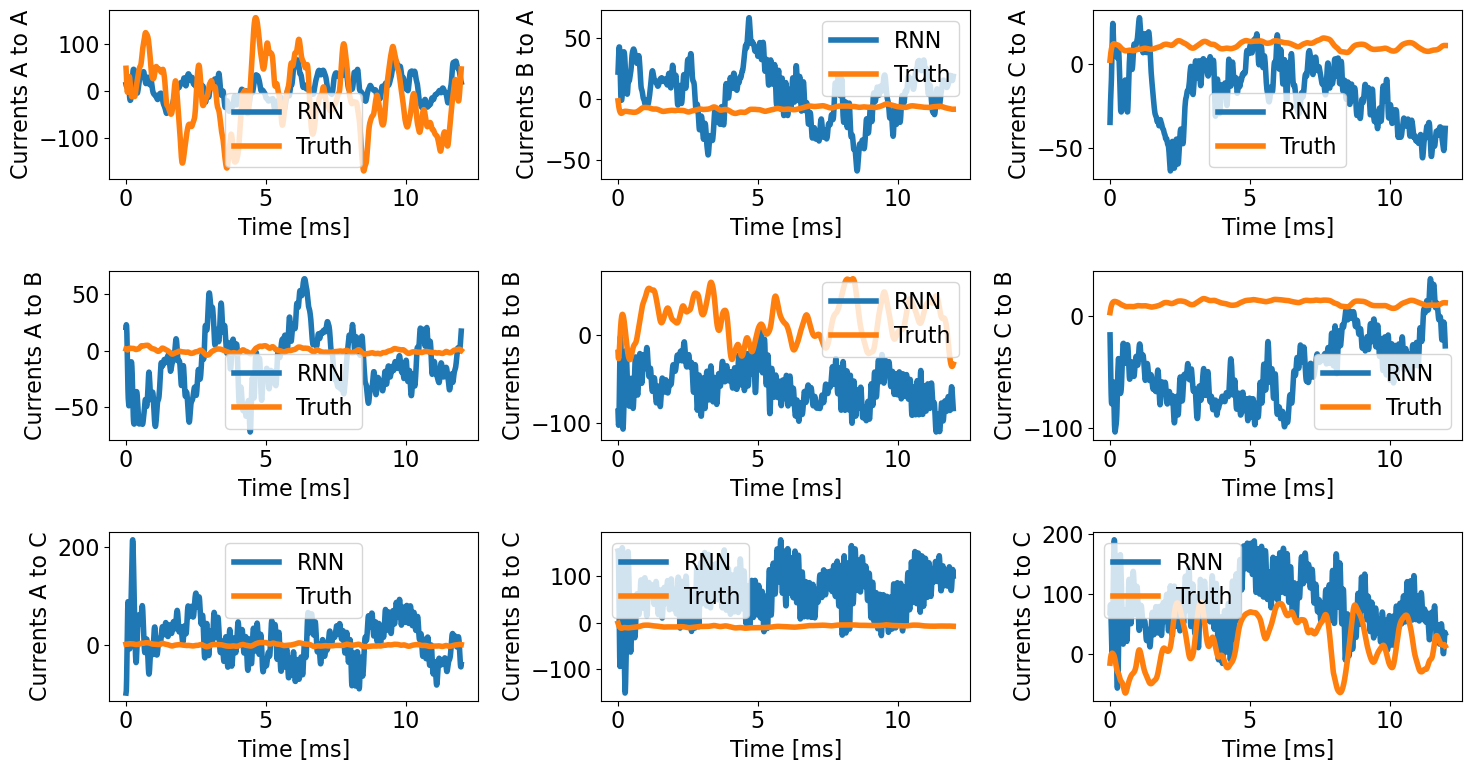

In [21]:
currents = compute_currents(network=net, region_size=1000, no_regions=3, activity=np.tanh(x))
currents_truth = compute_currents(network=model, region_size=1000, no_regions=3, activity=np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0))

fig, ax = plt.subplots(3, 3, figsize=(15, 8))

ax[0][0].plot(time, np.sum(currents[0], axis=0), label="RNN")
ax[0][0].plot(time, np.sum(currents_truth[0], axis=0), label="Truth")
ax[0][0].legend()
ax[0][0].set_xlabel("Time [ms]")
ax[0][0].set_ylabel("Currents A to A")

ax[0][1].plot(time, np.sum(currents[1], axis=0), label="RNN")
ax[0][1].plot(time, np.sum(currents_truth[1], axis=0), label="Truth")
ax[0][1].legend()
ax[0][1].set_xlabel("Time [ms]")
ax[0][1].set_ylabel("Currents B to A")

ax[0][2].plot(time, np.sum(currents[2], axis=0), label="RNN")
ax[0][2].plot(time, np.sum(currents_truth[2], axis=0), label="Truth")
ax[0][2].legend()
ax[0][2].set_xlabel("Time [ms]")
ax[0][2].set_ylabel("Currents C to A")

ax[1][0].plot(time, np.sum(currents[3], axis=0), label="RNN")
ax[1][0].plot(time, np.sum(currents_truth[3], axis=0), label="Truth")
ax[1][0].legend()
ax[1][0].set_xlabel("Time [ms]")
ax[1][0].set_ylabel("Currents A to B")

ax[1][1].plot(time, np.sum(currents[4], axis=0), label="RNN")
ax[1][1].plot(time, np.sum(currents_truth[4], axis=0), label="Truth")
ax[1][1].legend()
ax[1][1].set_xlabel("Time [ms]")
ax[1][1].set_ylabel("Currents B to B")

ax[1][2].plot(time, np.sum(currents[5], axis=0), label="RNN")
ax[1][2].plot(time, np.sum(currents_truth[5], axis=0), label="Truth")
ax[1][2].legend()
ax[1][2].set_xlabel("Time [ms]")
ax[1][2].set_ylabel("Currents C to B")

ax[2][0].plot(time, np.sum(currents[6], axis=0), label="RNN")
ax[2][0].plot(time, np.sum(currents_truth[6], axis=0), label="Truth")
ax[2][0].legend()
ax[2][0].set_xlabel("Time [ms]")
ax[2][0].set_ylabel("Currents A to C")

ax[2][1].plot(time, np.sum(currents[7], axis=0), label="RNN")
ax[2][1].plot(time, np.sum(currents_truth[7], axis=0), label="Truth")
ax[2][1].legend()
ax[2][1].set_xlabel("Time [ms]")
ax[2][1].set_ylabel("Currents B to C")

ax[2][2].plot(time, np.sum(currents[8], axis=0), label="RNN")
ax[2][2].plot(time, np.sum(currents_truth[8], axis=0), label="Truth")
ax[2][2].legend()
ax[2][2].set_xlabel("Time [ms]")
ax[2][2].set_ylabel("Currents C to C")

plt.tight_layout()
plt.show()

In [22]:
pca_RNN = [None] * len(currents)
for i, curr in enumerate(currents):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_RNN[i] = norm_component
    
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

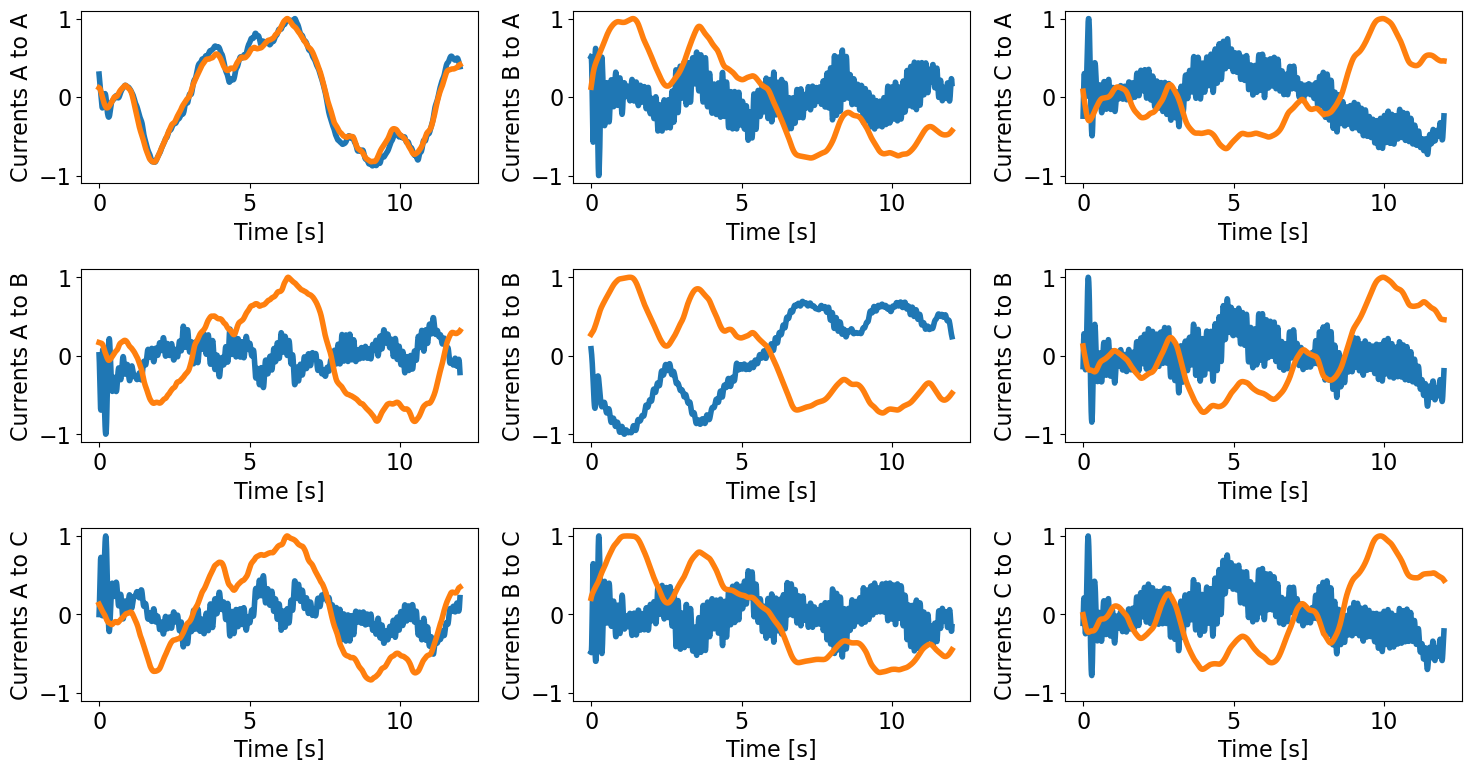

In [23]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))

ax[0][0].plot(time, pca_RNN[0], label="RNN")
ax[0][0].plot(time, pca_truth[0], label="Truth")
# ax[0][0].legend()
ax[0][0].set_ylim([-1.1, 1.1])
ax[0][0].set_xlabel("Time [s]")
ax[0][0].set_ylabel("Currents A to A")

ax[0][1].plot(time, -pca_RNN[1], label="RNN")
ax[0][1].plot(time, pca_truth[1], label="Truth")
# ax[0][1].legend()
ax[0][1].set_ylim([-1.1, 1.1])
ax[0][1].set_xlabel("Time [s]")
ax[0][1].set_ylabel("Currents B to A")

ax[0][2].plot(time, pca_RNN[2], label="RNN")
ax[0][2].plot(time, pca_truth[2], label="Truth")
# ax[0][2].legend()
ax[0][2].set_ylim([-1.1, 1.1])
ax[0][2].set_xlabel("Time [s]")
ax[0][2].set_ylabel("Currents C to A")

ax[1][0].plot(time, -pca_RNN[3], label="RNN")
ax[1][0].plot(time, pca_truth[3], label="Truth")
# ax[1][0].legend()
ax[1][0].set_ylim([-1.1, 1.1])
ax[1][0].set_xlabel("Time [s]")
ax[1][0].set_ylabel("Currents A to B")

ax[1][1].plot(time, -pca_RNN[4], label="RNN")
ax[1][1].plot(time, pca_truth[4], label="Truth")
# ax[1][1].legend()
ax[1][1].set_ylim([-1.1, 1.1])
ax[1][1].set_xlabel("Time [s]")
ax[1][1].set_ylabel("Currents B to B")

ax[1][2].plot(time, pca_RNN[5], label="RNN")
ax[1][2].plot(time, pca_truth[5], label="Truth")
# ax[1][2].legend()
ax[1][2].set_ylim([-1.1, 1.1])
ax[1][2].set_xlabel("Time [s]")
ax[1][2].set_ylabel("Currents C to B")

ax[2][0].plot(time, pca_RNN[6], label="RNN")
ax[2][0].plot(time, pca_truth[6], label="Truth")
# ax[2][0].legend()
ax[2][0].set_ylim([-1.1, 1.1])
ax[2][0].set_xlabel("Time [s]")
ax[2][0].set_ylabel("Currents A to C")

ax[2][1].plot(time, pca_RNN[7], label="RNN")
ax[2][1].plot(time, pca_truth[7], label="Truth")
# ax[2][1].legend()
ax[2][1].set_ylim([-1.1, 1.1])
ax[2][1].set_xlabel("Time [s]")
ax[2][1].set_ylabel("Currents B to C")

ax[2][2].plot(time, pca_RNN[8], label="RNN")
ax[2][2].plot(time, pca_truth[8], label="Truth")
# ax[2][2].legend()
ax[2][2].set_ylim([-1.1, 1.1])
ax[2][2].set_xlabel("Time [s]")
ax[2][2].set_ylabel("Currents C to C")

plt.tight_layout()
plt.show()

### Subsampling analysis

In [12]:
n = 300
teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)
currents_truth = compute_currents(network=model, region_size=1000, no_regions=3, activity=teacher)
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

N_trials = 5
all_pca_RNN = [np.empty((N_trials, 1200)) for i in range(9)]
for trial in range(N_trials):
    net = Network(N=n, tau=0.1, alpha=1.0)
    indices = np.random.choice(3000, size=n, replace=False)
    subset = teacher[indices]
    for i in tqdm(range(50)):
        x, J = net.learn(time, subset)
    currents = compute_currents(network=net, region_size=n//3, no_regions=3, activity=np.tanh(x))
    
    for i, curr in enumerate(currents):
        pca = PCA(n_components=2)
        components = pca.fit_transform(curr.T).T
        norm_component = components[0] / max(abs(components[0]))
        all_pca_RNN[i][trial, :] = norm_component[:]

np.save("CURBdata/3R_allPCA_n{}".format(n), all_pca_RNN)

100%|██████████| 50/50 [00:41<00:00,  1.21it/s]


In [24]:
teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)
currents_truth = compute_currents(network=model, region_size=1000, no_regions=3, activity=teacher)
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

all_pca_RNN = np.load("CURBdata/3R_allPCA_n300.npy")
for i, pca in enumerate(all_pca_RNN):
    truth = pca_truth[i]
    for j, trial in enumerate(pca):
        diff_pos = np.sum((trial - truth)**2)
        diff_neg = np.sum((-trial - truth)**2)
        if diff_pos > diff_neg:
            all_pca_RNN[i][j] = -trial

FileNotFoundError: [Errno 2] No such file or directory: 'CURBdata/3R_allPCA_n300.npy'

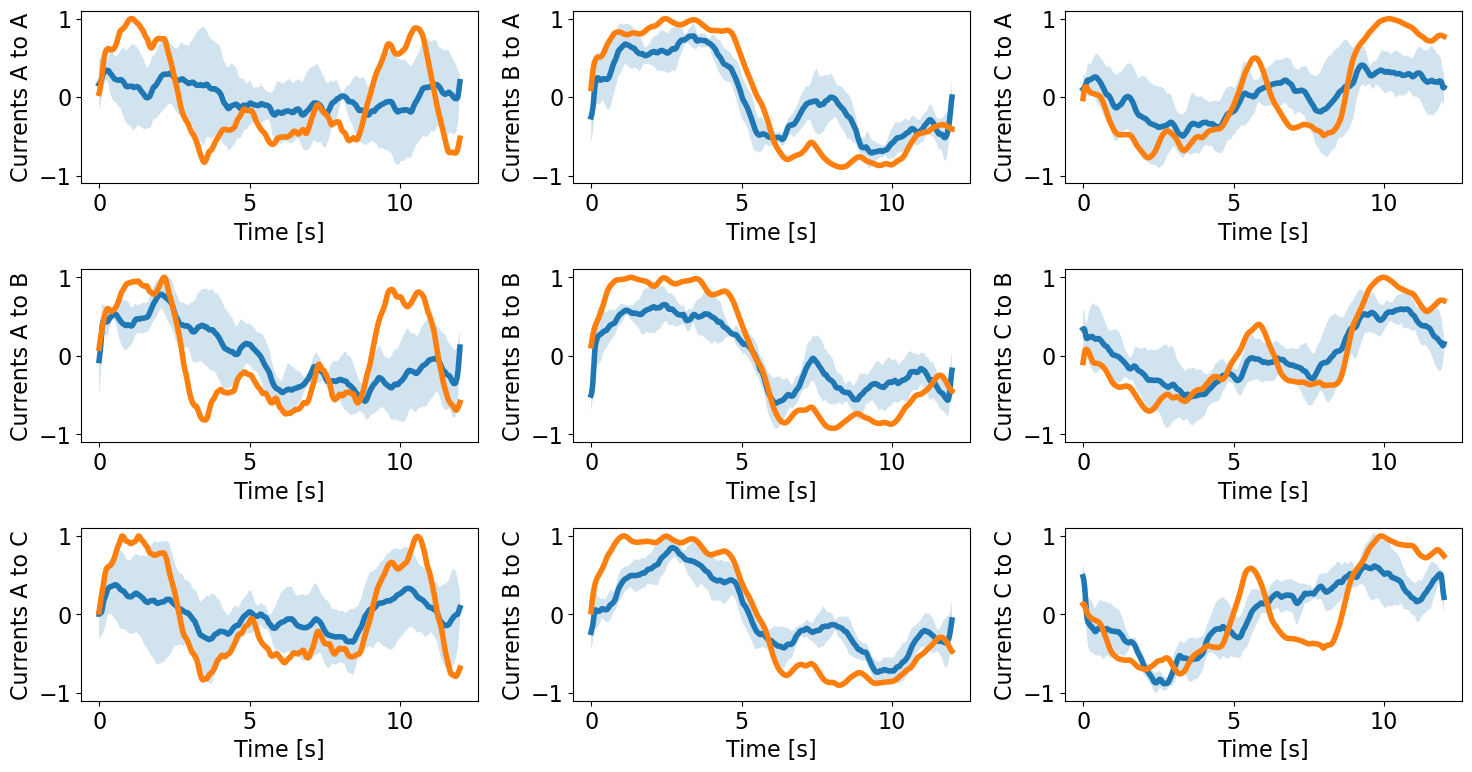

In [14]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))

mean, std = np.mean(all_pca_RNN[0], axis=0), np.std(all_pca_RNN[0], axis=0)
ax[0][0].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[0][0].plot(time, mean, label="RNN")
ax[0][0].plot(time, pca_truth[0], label="Truth")
# ax[0][0].legend()
ax[0][0].set_ylim([-1.1, 1.1])
ax[0][0].set_xlabel("Time [s]")
ax[0][0].set_ylabel("Currents A to A")

mean, std = np.mean(all_pca_RNN[1], axis=0), np.std(all_pca_RNN[1], axis=0)
ax[0][1].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[0][1].plot(time, mean, label="RNN")
ax[0][1].plot(time, pca_truth[1], label="Truth")
# ax[0][1].legend()
ax[0][1].set_ylim([-1.1, 1.1])
ax[0][1].set_xlabel("Time [s]")
ax[0][1].set_ylabel("Currents B to A")

mean, std = np.mean(all_pca_RNN[2], axis=0), np.std(all_pca_RNN[2], axis=0)
ax[0][2].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[0][2].plot(time, mean, label="RNN")
ax[0][2].plot(time, pca_truth[2], label="Truth")
# ax[0][2].legend()
ax[0][2].set_ylim([-1.1, 1.1])
ax[0][2].set_xlabel("Time [s]")
ax[0][2].set_ylabel("Currents C to A")

mean, std = np.mean(all_pca_RNN[3], axis=0), np.std(all_pca_RNN[3], axis=0)
ax[1][0].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[1][0].plot(time, mean, label="RNN")
ax[1][0].plot(time, pca_truth[3], label="Truth")
# ax[1][0].legend()
ax[1][0].set_ylim([-1.1, 1.1])
ax[1][0].set_xlabel("Time [s]")
ax[1][0].set_ylabel("Currents A to B")

mean, std = np.mean(all_pca_RNN[4], axis=0), np.std(all_pca_RNN[4], axis=0)
ax[1][1].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[1][1].plot(time, mean, label="RNN")
ax[1][1].plot(time, pca_truth[4], label="Truth")
# ax[1][1].legend()
ax[1][1].set_ylim([-1.1, 1.1])
ax[1][1].set_xlabel("Time [s]")
ax[1][1].set_ylabel("Currents B to B")

mean, std = np.mean(all_pca_RNN[5], axis=0), np.std(all_pca_RNN[5], axis=0)
ax[1][2].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[1][2].plot(time, mean, label="RNN")
ax[1][2].plot(time, pca_truth[5], label="Truth")
# ax[1][2].legend()
ax[1][2].set_ylim([-1.1, 1.1])
ax[1][2].set_xlabel("Time [s]")
ax[1][2].set_ylabel("Currents C to B")

mean, std = np.mean(all_pca_RNN[6], axis=0), np.std(all_pca_RNN[6], axis=0)
ax[2][0].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[2][0].plot(time, mean, label="RNN")
ax[2][0].plot(time, pca_truth[6], label="Truth")
# ax[2][0].legend()
ax[2][0].set_ylim([-1.1, 1.1])
ax[2][0].set_xlabel("Time [s]")
ax[2][0].set_ylabel("Currents A to C")

mean, std = np.mean(all_pca_RNN[7], axis=0), np.std(all_pca_RNN[7], axis=0)
ax[2][1].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[2][1].plot(time, mean, label="RNN")
ax[2][1].plot(time, pca_truth[7], label="Truth")
# ax[2][1].legend()
ax[2][1].set_ylim([-1.1, 1.1])
ax[2][1].set_xlabel("Time [s]")
ax[2][1].set_ylabel("Currents B to C")

mean, std = np.mean(all_pca_RNN[8], axis=0), np.std(all_pca_RNN[8], axis=0)
ax[2][2].fill_between(time, y1=mean-std, y2=mean+std, alpha=0.2)
ax[2][2].plot(time, mean, label="RNN")
ax[2][2].plot(time, pca_truth[8], label="Truth")
# ax[2][2].legend()
ax[2][2].set_ylim([-1.1, 1.1])
ax[2][2].set_xlabel("Time [s]")
ax[2][2].set_ylabel("Currents C to C")

plt.tight_layout()
plt.show()

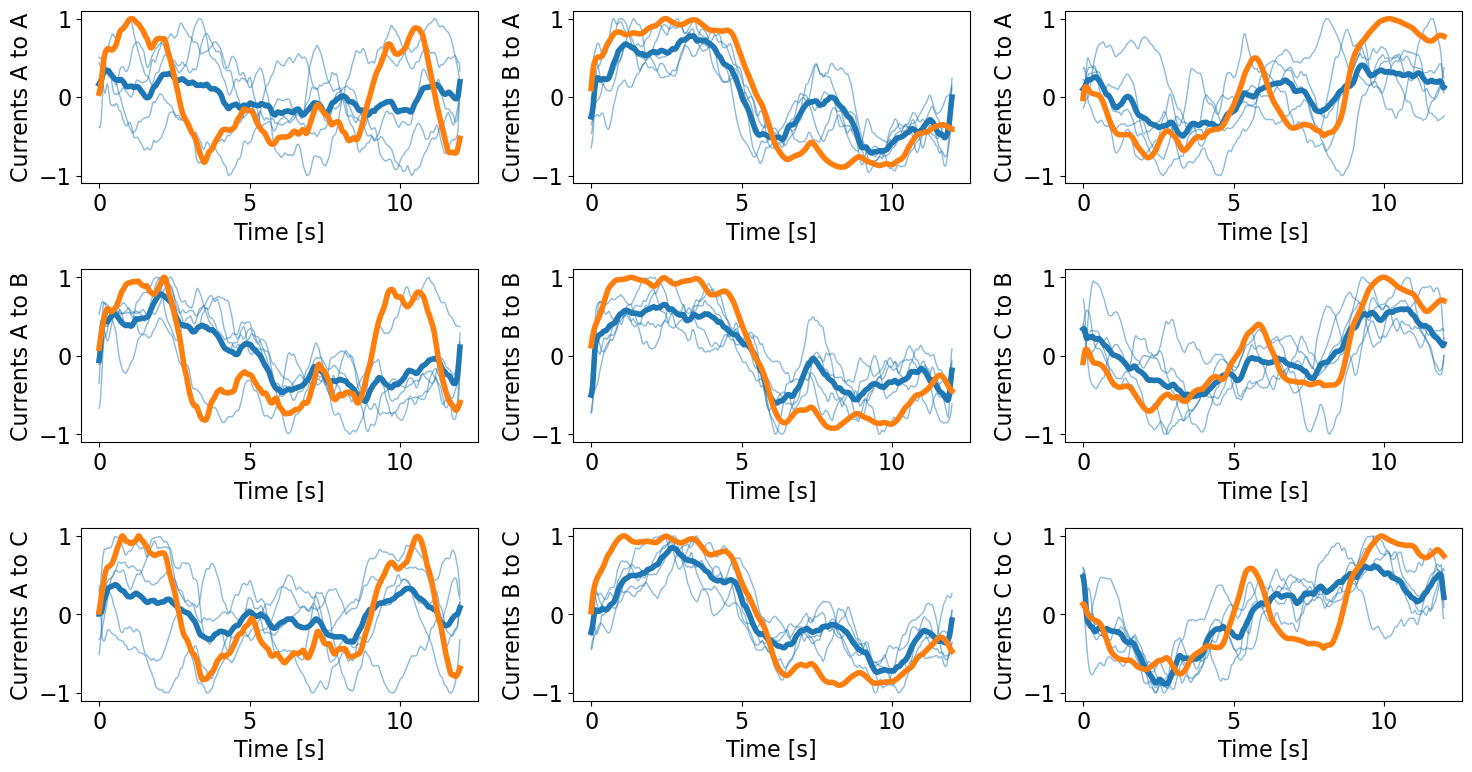

In [15]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))

mean = np.mean(all_pca_RNN[0], axis=0)
ax[0][0].plot(time, all_pca_RNN[0].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[0][0].plot(time, mean, label="RNN")
ax[0][0].plot(time, pca_truth[0], label="Truth")
# ax[0][0].legend()
ax[0][0].set_ylim([-1.1, 1.1])
ax[0][0].set_xlabel("Time [s]")
ax[0][0].set_ylabel("Currents A to A")

mean = np.mean(all_pca_RNN[1], axis=0)
ax[0][1].plot(time, all_pca_RNN[1].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[0][1].plot(time, mean, label="RNN")
ax[0][1].plot(time, pca_truth[1], label="Truth")
# ax[0][1].legend()
ax[0][1].set_ylim([-1.1, 1.1])
ax[0][1].set_xlabel("Time [s]")
ax[0][1].set_ylabel("Currents B to A")

mean = np.mean(all_pca_RNN[2], axis=0)
ax[0][2].plot(time, all_pca_RNN[2].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[0][2].plot(time, mean, label="RNN")
ax[0][2].plot(time, pca_truth[2], label="Truth")
# ax[0][2].legend()
ax[0][2].set_ylim([-1.1, 1.1])
ax[0][2].set_xlabel("Time [s]")
ax[0][2].set_ylabel("Currents C to A")

mean = np.mean(all_pca_RNN[3], axis=0)
ax[1][0].plot(time, all_pca_RNN[3].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[1][0].plot(time, mean, label="RNN")
ax[1][0].plot(time, pca_truth[3], label="Truth")
# ax[1][0].legend()
ax[1][0].set_ylim([-1.1, 1.1])
ax[1][0].set_xlabel("Time [s]")
ax[1][0].set_ylabel("Currents A to B")

mean = np.mean(all_pca_RNN[4], axis=0)
ax[1][1].plot(time, all_pca_RNN[4].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[1][1].plot(time, mean, label="RNN")
ax[1][1].plot(time, pca_truth[4], label="Truth")
# ax[1][1].legend()
ax[1][1].set_ylim([-1.1, 1.1])
ax[1][1].set_xlabel("Time [s]")
ax[1][1].set_ylabel("Currents B to B")

mean = np.mean(all_pca_RNN[5], axis=0)
ax[1][2].plot(time, all_pca_RNN[5].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[1][2].plot(time, mean, label="RNN")
ax[1][2].plot(time, pca_truth[5], label="Truth")
# ax[1][2].legend()
ax[1][2].set_ylim([-1.1, 1.1])
ax[1][2].set_xlabel("Time [s]")
ax[1][2].set_ylabel("Currents C to B")

mean = np.mean(all_pca_RNN[6], axis=0)
ax[2][0].plot(time, all_pca_RNN[6].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(time, mean, label="RNN")
ax[2][0].plot(time, pca_truth[6], label="Truth")
# ax[2][0].legend()
ax[2][0].set_ylim([-1.1, 1.1])
ax[2][0].set_xlabel("Time [s]")
ax[2][0].set_ylabel("Currents A to C")

mean = np.mean(all_pca_RNN[7], axis=0)
ax[2][1].plot(time, all_pca_RNN[7].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[2][1].plot(time, mean, label="RNN")
ax[2][1].plot(time, pca_truth[7], label="Truth")
# ax[2][1].legend()
ax[2][1].set_ylim([-1.1, 1.1])
ax[2][1].set_xlabel("Time [s]")
ax[2][1].set_ylabel("Currents B to C")

mean = np.mean(all_pca_RNN[8], axis=0)
ax[2][2].plot(time, all_pca_RNN[8].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[2][2].plot(time, mean, label="RNN")
ax[2][2].plot(time, pca_truth[8], label="Truth")
# ax[2][2].legend()
ax[2][2].set_ylim([-1.1, 1.1])
ax[2][2].set_xlabel("Time [s]")
ax[2][2].set_ylabel("Currents C to C")

plt.tight_layout()
plt.show()

In [16]:
n = 300
teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)
currents_truth = compute_currents(network=model, region_size=1000, no_regions=3, activity=teacher)
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

N_trials = 25
indices = np.random.choice(3000, size=n, replace=False)
subset = teacher[indices]
all_pca_RNN = [np.empty((N_trials, 1200)) for i in range(9)]
for trial in range(N_trials):
    net = Network(N=n, tau=0.1, alpha=1.0)
    for i in tqdm(range(50)):
        x, J = net.learn(time, subset)
    currents = compute_currents(network=net, region_size=n//3, no_regions=3, activity=np.tanh(x))
    
    for i, curr in enumerate(currents):
        pca = PCA(n_components=2)
        components = pca.fit_transform(curr.T).T
        norm_component = components[0] / max(abs(components[0]))
        all_pca_RNN[i][trial, :] = norm_component[:]

np.save("CURBdata/3R_allPCA_fixn{}".format(n), all_pca_RNN)

100%|██████████| 50/50 [00:39<00:00,  1.26it/s]


In [17]:
teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)
currents_truth = compute_currents(network=model, region_size=1000, no_regions=3, activity=teacher)
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

all_pca_RNN = np.load("CURBdata/3R_allPCA_fixn300.npy")
for i, pca in enumerate(all_pca_RNN):
    truth = pca_truth[i]
    for j, trial in enumerate(pca):
        diff_pos = np.sum((trial - truth)**2)
        diff_neg = np.sum((-trial - truth)**2)
        if diff_pos > diff_neg:
            all_pca_RNN[i][j] = -trial

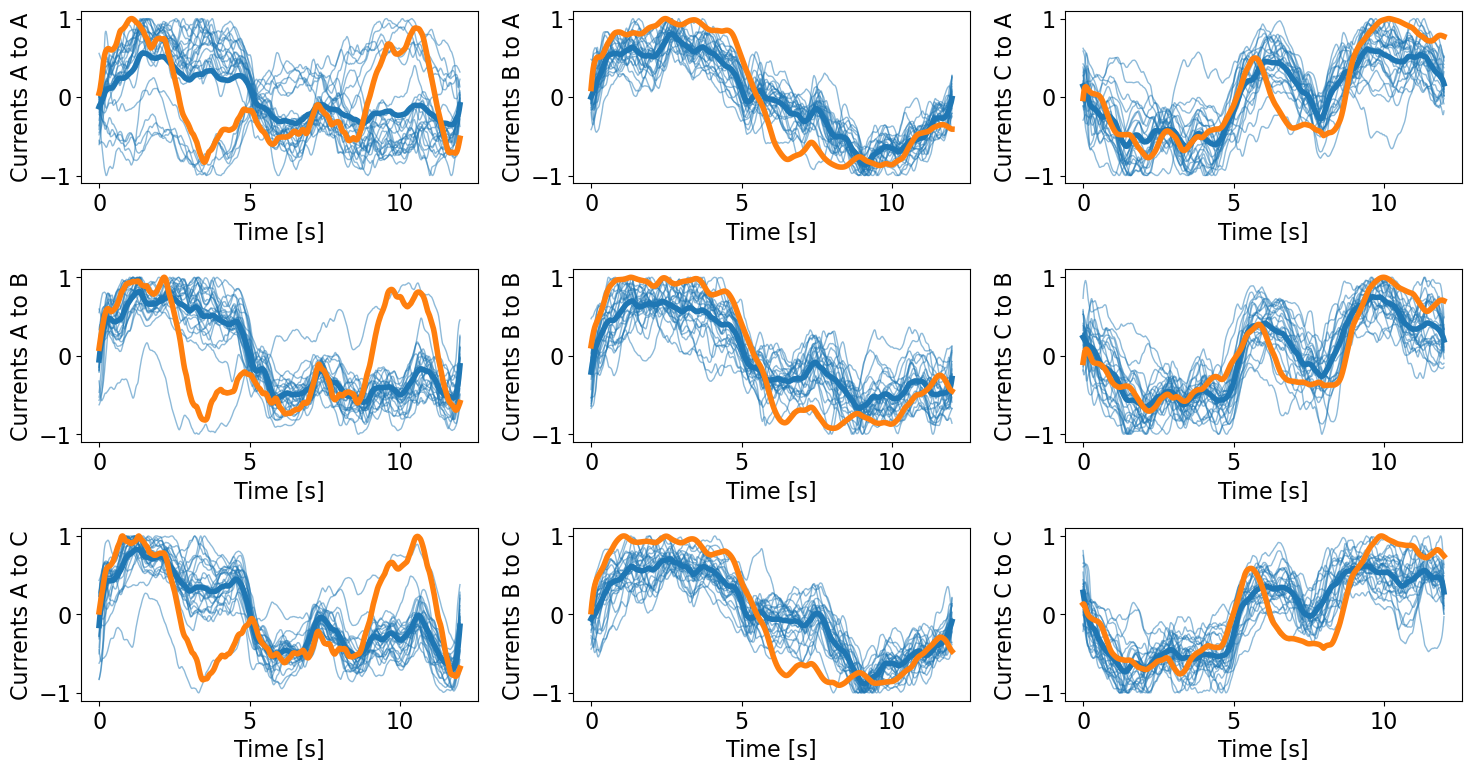

In [18]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))

mean = np.mean(all_pca_RNN[0], axis=0)
ax[0][0].plot(time, all_pca_RNN[0].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[0][0].plot(time, mean, label="RNN")
ax[0][0].plot(time, pca_truth[0], label="Truth")
# ax[0][0].legend()
ax[0][0].set_ylim([-1.1, 1.1])
ax[0][0].set_xlabel("Time [s]")
ax[0][0].set_ylabel("Currents A to A")

mean = np.mean(all_pca_RNN[1], axis=0)
ax[0][1].plot(time, all_pca_RNN[1].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[0][1].plot(time, mean, label="RNN")
ax[0][1].plot(time, pca_truth[1], label="Truth")
# ax[0][1].legend()
ax[0][1].set_ylim([-1.1, 1.1])
ax[0][1].set_xlabel("Time [s]")
ax[0][1].set_ylabel("Currents B to A")

mean = np.mean(all_pca_RNN[2], axis=0)
ax[0][2].plot(time, all_pca_RNN[2].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[0][2].plot(time, mean, label="RNN")
ax[0][2].plot(time, pca_truth[2], label="Truth")
# ax[0][2].legend()
ax[0][2].set_ylim([-1.1, 1.1])
ax[0][2].set_xlabel("Time [s]")
ax[0][2].set_ylabel("Currents C to A")

mean = np.mean(all_pca_RNN[3], axis=0)
ax[1][0].plot(time, all_pca_RNN[3].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[1][0].plot(time, mean, label="RNN")
ax[1][0].plot(time, pca_truth[3], label="Truth")
# ax[1][0].legend()
ax[1][0].set_ylim([-1.1, 1.1])
ax[1][0].set_xlabel("Time [s]")
ax[1][0].set_ylabel("Currents A to B")

mean = np.mean(all_pca_RNN[4], axis=0)
ax[1][1].plot(time, all_pca_RNN[4].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[1][1].plot(time, mean, label="RNN")
ax[1][1].plot(time, pca_truth[4], label="Truth")
# ax[1][1].legend()
ax[1][1].set_ylim([-1.1, 1.1])
ax[1][1].set_xlabel("Time [s]")
ax[1][1].set_ylabel("Currents B to B")

mean = np.mean(all_pca_RNN[5], axis=0)
ax[1][2].plot(time, all_pca_RNN[5].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[1][2].plot(time, mean, label="RNN")
ax[1][2].plot(time, pca_truth[5], label="Truth")
# ax[1][2].legend()
ax[1][2].set_ylim([-1.1, 1.1])
ax[1][2].set_xlabel("Time [s]")
ax[1][2].set_ylabel("Currents C to B")

mean = np.mean(all_pca_RNN[6], axis=0)
ax[2][0].plot(time, all_pca_RNN[6].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[2][0].plot(time, mean, label="RNN")
ax[2][0].plot(time, pca_truth[6], label="Truth")
# ax[2][0].legend()
ax[2][0].set_ylim([-1.1, 1.1])
ax[2][0].set_xlabel("Time [s]")
ax[2][0].set_ylabel("Currents A to C")

mean = np.mean(all_pca_RNN[7], axis=0)
ax[2][1].plot(time, all_pca_RNN[7].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[2][1].plot(time, mean, label="RNN")
ax[2][1].plot(time, pca_truth[7], label="Truth")
# ax[2][1].legend()
ax[2][1].set_ylim([-1.1, 1.1])
ax[2][1].set_xlabel("Time [s]")
ax[2][1].set_ylabel("Currents B to C")

mean = np.mean(all_pca_RNN[8], axis=0)
ax[2][2].plot(time, all_pca_RNN[8].T, color="tab:blue", linewidth=1, alpha=0.5)
ax[2][2].plot(time, mean, label="RNN")
ax[2][2].plot(time, pca_truth[8], label="Truth")
# ax[2][2].legend()
ax[2][2].set_ylim([-1.1, 1.1])
ax[2][2].set_xlabel("Time [s]")
ax[2][2].set_ylabel("Currents C to C")

plt.tight_layout()
plt.show()

### Coarse resolution analysis

In [8]:
def sum_by_bunch(array, M):
    N, T = array.shape
    bunch_size = N // M
    remainder = N % M
    bunch_sizes = [bunch_size] * M
    for i in range(remainder):
        bunch_sizes[i] += 1
    output = np.zeros((M, T))
    idx = 0
    for bunch_size in bunch_sizes:
        output[idx] = np.mean(array[idx* bunch_size:(idx + 1)*bunch_size], axis=0)
        idx += 1
    return output

In [9]:
teacher = np.concatenate((np.tanh(rA), np.tanh(rB), np.tanh(rC)), axis=0)
currents_truth = compute_currents(network=model, region_size=1000, no_regions=3, activity=teacher)
pca_truth = [None] * len(currents_truth)
for i, curr in enumerate(currents_truth):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_truth[i] = norm_component

In [11]:
gr = 1500
subset = sum_by_bunch(teacher, gr)
net = Network(N=gr, tau=0.1, alpha=1.0)
for i in tqdm(range(50)):
    x, J = net.learn(time, subset)
    
currents_RNN = compute_currents(network=net, region_size=gr//3, no_regions=3, activity=np.tanh(x))
pca_RNN = np.empty((len(currents_RNN), len(time))) 
for i, curr in enumerate(currents_RNN):
    pca = PCA(n_components=2)
    components = pca.fit_transform(curr.T).T
    norm_component = components[0] / max(abs(components[0]))
    pca_RNN[i, :] = norm_component

np.save("CURBdata/3R_PCA_gr{}".format(gr), pca_RNN)

  0%|          | 0/50 [00:02<?, ?it/s]


KeyboardInterrupt: 

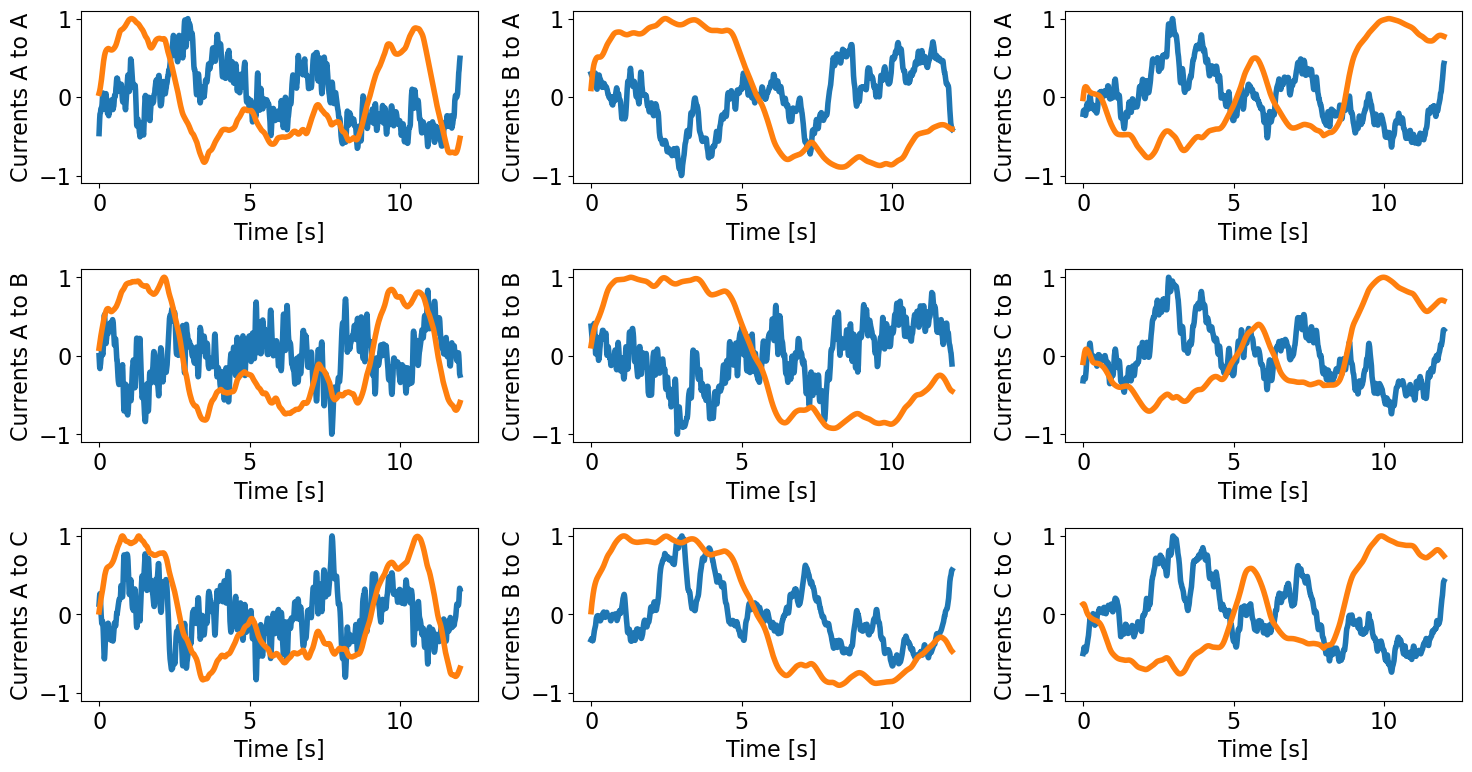

In [12]:
pca_RNN = np.load("CURBdata/3R_PCA_gr300.npy")
fig, ax = plt.subplots(3, 3, figsize=(15, 8))

ax[0][0].plot(time, pca_RNN[0], label="RNN")
ax[0][0].plot(time, pca_truth[0], label="Truth")
# ax[0][0].legend()
ax[0][0].set_ylim([-1.1, 1.1])
ax[0][0].set_xlabel("Time [s]")
ax[0][0].set_ylabel("Currents A to A")

ax[0][1].plot(time, -pca_RNN[1], label="RNN")
ax[0][1].plot(time, pca_truth[1], label="Truth")
# ax[0][1].legend()
ax[0][1].set_ylim([-1.1, 1.1])
ax[0][1].set_xlabel("Time [s]")
ax[0][1].set_ylabel("Currents B to A")

ax[0][2].plot(time, pca_RNN[2], label="RNN")
ax[0][2].plot(time, pca_truth[2], label="Truth")
# ax[0][2].legend()
ax[0][2].set_ylim([-1.1, 1.1])
ax[0][2].set_xlabel("Time [s]")
ax[0][2].set_ylabel("Currents C to A")

ax[1][0].plot(time, -pca_RNN[3], label="RNN")
ax[1][0].plot(time, pca_truth[3], label="Truth")
# ax[1][0].legend()
ax[1][0].set_ylim([-1.1, 1.1])
ax[1][0].set_xlabel("Time [s]")
ax[1][0].set_ylabel("Currents A to B")

ax[1][1].plot(time, -pca_RNN[4], label="RNN")
ax[1][1].plot(time, pca_truth[4], label="Truth")
# ax[1][1].legend()
ax[1][1].set_ylim([-1.1, 1.1])
ax[1][1].set_xlabel("Time [s]")
ax[1][1].set_ylabel("Currents B to B")

ax[1][2].plot(time, pca_RNN[5], label="RNN")
ax[1][2].plot(time, pca_truth[5], label="Truth")
# ax[1][2].legend()
ax[1][2].set_ylim([-1.1, 1.1])
ax[1][2].set_xlabel("Time [s]")
ax[1][2].set_ylabel("Currents C to B")

ax[2][0].plot(time, pca_RNN[6], label="RNN")
ax[2][0].plot(time, pca_truth[6], label="Truth")
# ax[2][0].legend()
ax[2][0].set_ylim([-1.1, 1.1])
ax[2][0].set_xlabel("Time [s]")
ax[2][0].set_ylabel("Currents A to C")

ax[2][1].plot(time, pca_RNN[7], label="RNN")
ax[2][1].plot(time, pca_truth[7], label="Truth")
# ax[2][1].legend()
ax[2][1].set_ylim([-1.1, 1.1])
ax[2][1].set_xlabel("Time [s]")
ax[2][1].set_ylabel("Currents B to C")

ax[2][2].plot(time, pca_RNN[8], label="RNN")
ax[2][2].plot(time, pca_truth[8], label="Truth")
# ax[2][2].legend()
ax[2][2].set_ylim([-1.1, 1.1])
ax[2][2].set_xlabel("Time [s]")
ax[2][2].set_ylabel("Currents C to C")

plt.tight_layout()
plt.show()